In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
# Load documents from the "crew_data" directory

from langchain_community.document_loaders import PyPDFLoader

file_path = "crew_data/doc.pdf"   # <-- ONLY original file

loader = PyPDFLoader(file_path)
docs = loader.load()

print("Pages loaded:", len(docs))

Pages loaded: 6


In [4]:
# Chunk the documents into smaller pieces

from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=80
)

chunks = text_splitter.split_documents(docs)

# Remove tiny chunks
chunks = [c for c in chunks if len(c.page_content.strip()) > 50]

print("Clean chunks:", len(chunks))

Clean chunks: 56


In [ ]:
# Create Embeddings + FAISS Vectorstore

from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

vectorstore = FAISS.from_documents(chunks, embeddings)

print("Vectorstore created")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Vectorstore created


In [7]:
# TEST SIMILARITY SEARCH

query = "What is clinical summarization?"

results = vectorstore.similarity_search_with_score(query, k=3)

for i, (doc, score) in enumerate(results):
    print(f"\nResult {i+1} (Score: {score})")
    print(doc.page_content[:300])


Result 1 (Score: 0.39705055952072144)
unstructured across thousands of progress notes, lab results, office visits, phone call transcriptions, and the like. Clinical
summarization involves condensing this unstructured information into an accurate picture of a patient’s medical history
and current health status into a concise, accessible 

Result 2 (Score: 0.4670615792274475)
American healthcare, clinicians have diverse ways of approaching clinical summarization – with many placing much
time, energy, and value, while others not so much.
Tools that streamline the clinical summarization process have been a hot topic of debate, with many arguing for its
effectiveness in hea

Result 3 (Score: 0.5573083758354187)
the aforementioned issues in clinical summarization using AI agents. Several case studies verify AI usage in various
clinical settings to aid in chart review and summarization of clinical information.
3


In [ ]:
# TEST MULTIPLE QUERIES

queries = [
    "What is AI in healthcare?",
    "How does summarization work?",
    "What are clinical workflows?",
    "What is generative AI used for?"
]

for q in queries:
    print("\n\nQUERY:", q)
    results = vectorstore.similarity_search(q, k=2)

    for i, doc in enumerate(results):
        print("\n-", doc.page_content[:300])



QUERY: What is AI in healthcare?

- Future developments in this field must focus on refining AI technologies, improving their adaptability, and ensuring
they align with the overarching goal of improving patient outcomes.
As AI continues to evolve, future research will likely explore more sophisticated models that can handle a wider
ra

- socioeconomic bias in AI algorithms and the impact of automation on employment within the healthcare sector, will
need to be carefully considered.
References
[1] O’Malley AS, Cohen GR, Grossman JM. Electronic medical records and communication with patients and other
clinicians: are we talking less? 


QUERY: How does summarization work?

- unstructured across thousands of progress notes, lab results, office visits, phone call transcriptions, and the like. Clinical
summarization involves condensing this unstructured information into an accurate picture of a patient’s medical history
and current health status into a concise, accessible 

- the aforemen

In [9]:
# Create embeddings manually to check dimensions

embedding_model = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

vectors = [embedding_model.embed_query(chunk.page_content) for chunk in chunks]
vectors = np.array(vectors)

print("Embedding shape:", vectors.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Embedding shape: (56, 384)


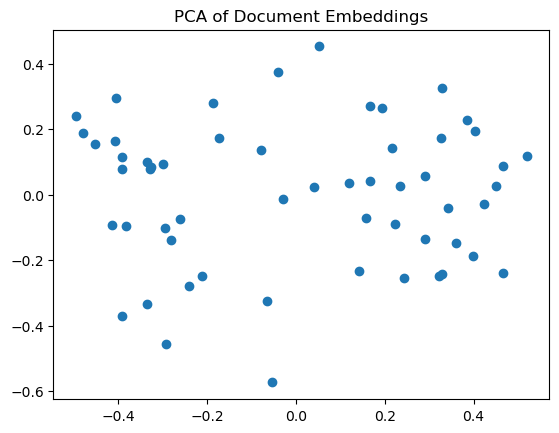

In [10]:
# PCA Visualization of the embeddings

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced = pca.fit_transform(vectors)

plt.figure()
plt.scatter(reduced[:, 0], reduced[:, 1])
plt.title("PCA of Document Embeddings")
plt.show()

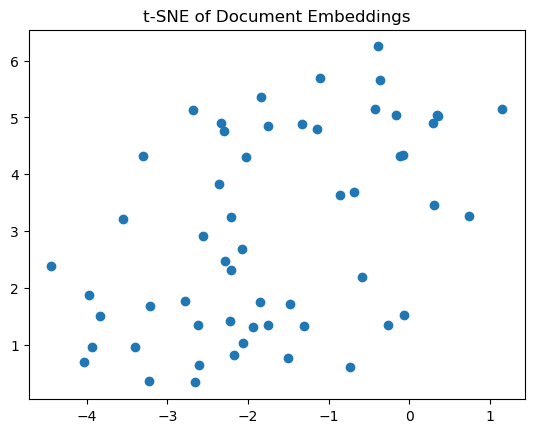

In [11]:
# t-SNE Visualization of the embeddings

from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30, random_state=42)
reduced_tsne = tsne.fit_transform(vectors)

plt.figure()
plt.scatter(reduced_tsne[:, 0], reduced_tsne[:, 1])
plt.title("t-SNE of Document Embeddings")
plt.show()

Task 2

In [12]:
# Load MULTIPLE documents

from langchain_community.document_loaders import PyPDFLoader, TextLoader
import os

docs = []
folder_path = "crew_data"

for file in os.listdir(folder_path):
    path = os.path.join(folder_path, file)

    if file.endswith(".pdf"):
        loader = PyPDFLoader(path)
        docs.extend(loader.load())

    elif file.endswith(".txt"):
        loader = TextLoader(path)
        docs.extend(loader.load())

print("Total documents loaded:", len(docs))

Total documents loaded: 6


In [13]:
# Chunk all documents

from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=80
)

chunks = text_splitter.split_documents(docs)
chunks = [c for c in chunks if len(c.page_content.strip()) > 50]

print("Total chunks:", len(chunks))

Total chunks: 56


In [14]:
# Rebuild FAISS Vectorstore with new chunks 

from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")

vectorstore = FAISS.from_documents(chunks, embeddings)

print("FAISS rebuilt with expanded knowledge base")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

FAISS rebuilt with expanded knowledge base


In [15]:
# Test retrieval with new queries

queries = [
    "What is AI in healthcare?",
    "How is AI used in education?",
    "Applications of AI",
    "Explain clinical summarization"
]

for q in queries:
    print("\nQUERY:", q)

    results = vectorstore.similarity_search(q, k=2)

    for i, doc in enumerate(results):
        print(f"\nResult {i+1}:")
        print(doc.page_content[:300])


QUERY: What is AI in healthcare?

Result 1:
Future developments in this field must focus on refining AI technologies, improving their adaptability, and ensuring
they align with the overarching goal of improving patient outcomes.
As AI continues to evolve, future research will likely explore more sophisticated models that can handle a wider
ra

Result 2:
socioeconomic bias in AI algorithms and the impact of automation on employment within the healthcare sector, will
need to be carefully considered.
References
[1] O’Malley AS, Cohen GR, Grossman JM. Electronic medical records and communication with patients and other
clinicians: are we talking less? 

QUERY: How is AI used in education?

Result 1:
Future developments in this field must focus on refining AI technologies, improving their adaptability, and ensuring
they align with the overarching goal of improving patient outcomes.
As AI continues to evolve, future research will likely explore more sophisticated models that can handle a wi

In [17]:
# RAG pipeline using FREE model

from transformers import pipeline
#from langchain.llms import HuggingFacePipeline
#from langchain_community.llms import HuggingFacePipeline
from langchain_huggingface import HuggingFacePipeline
from langchain_classic.chains import RetrievalQA

pipe = pipeline(
    "text-generation",
    model="google/flan-t5-base",
    max_new_tokens=256
)

# Convert to LangChain LLM
llm = HuggingFacePipeline(pipeline=pipe)

# Create retriever from vectorstore
retriever = vectorstore.as_retriever(search_kwargs={"k": 3})

# Create RAG chain
qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    retriever=retriever
)



Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCa

In [18]:
#  Test RAG with some questions

questions = [
    "What is AI in healthcare?",
    "How does AI help education?",
    "Benefits of AI in real life"
]

for q in questions:
    print("\nQ:", q)
    print("A:", qa_chain.run(q))


Q: What is AI in healthcare?


C:\Users\Farhaan\AppData\Local\Temp\ipykernel_17824\392091855.py:11: LangChainDeprecationWarning: The method `Chain.run` was deprecated in langchain-classic 0.1.0 and will be removed in 1.0. Use `invoke` instead.
  print("A:", qa_chain.run(q))
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


A: Use the following pieces of context to answer the question at the end. If you don't know the answer, just say that you don't know, don't try to make up an answer.

Future developments in this field must focus on refining AI technologies, improving their adaptability, and ensuring
they align with the overarching goal of improving patient outcomes.
As AI continues to evolve, future research will likely explore more sophisticated models that can handle a wider
range of data types and clinical scenarios. Additionally, the ethical implications of AI in healthcare, such as racial or

socioeconomic bias in AI algorithms and the impact of automation on employment within the healthcare sector, will
need to be carefully considered.
References
[1] O’Malley AS, Cohen GR, Grossman JM. Electronic medical records and communication with patients and other
clinicians: are we talking less? Issue Brief Cent Stud Health Syst Change . 2010 Apr;(131):1–4. PMID: 20499485.
[2] Buchan K, Filannino M, Uzuner

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


A: Use the following pieces of context to answer the question at the end. If you don't know the answer, just say that you don't know, don't try to make up an answer.

Future developments in this field must focus on refining AI technologies, improving their adaptability, and ensuring
they align with the overarching goal of improving patient outcomes.
As AI continues to evolve, future research will likely explore more sophisticated models that can handle a wider
range of data types and clinical scenarios. Additionally, the ethical implications of AI in healthcare, such as racial or

medical errors and physician burnout.
5 The Role of AI in Clinical Summarization
The growing crisis in healthcare information volume, physician burnout, and patient-physician relations, increasing
efforts to incorporate artificial intelligence into clinical summarization. Natural language processing (NLP) can be
used to determine illnesses or patient information from clinical free-text. [19] The increasing ca

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


A: Use the following pieces of context to answer the question at the end. If you don't know the answer, just say that you don't know, don't try to make up an answer.

Future developments in this field must focus on refining AI technologies, improving their adaptability, and ensuring
they align with the overarching goal of improving patient outcomes.
As AI continues to evolve, future research will likely explore more sophisticated models that can handle a wider
range of data types and clinical scenarios. Additionally, the ethical implications of AI in healthcare, such as racial or

socioeconomic bias in AI algorithms and the impact of automation on employment within the healthcare sector, will
need to be carefully considered.
References
[1] O’Malley AS, Cohen GR, Grossman JM. Electronic medical records and communication with patients and other
clinicians: are we talking less? Issue Brief Cent Stud Health Syst Change . 2010 Apr;(131):1–4. PMID: 20499485.
[2] Buchan K, Filannino M, Uzuner

In [26]:
# Test the RAG chain with multiple questions

questions = [
    "Explain clinical summarization in simple terms",
    "What are benefits of AI in clinical summarization?",
    "What challenges exist in healthcare AI?",
    "How does AI improve clinical workflows?"
]

for q in questions:
    print("\nQ:", q)
    print("A:", qa_chain.run(q))


Q: Explain clinical summarization in simple terms
A: Use the following pieces of context to answer the question at the end. If you don't know the answer, just say that you don't know, don't try to make up an answer.

unstructured across thousands of progress notes, lab results, office visits, phone call transcriptions, and the like. Clinical
summarization involves condensing this unstructured information into an accurate picture of a patient’s medical history
and current health status into a concise, accessible format. This practice has significant implications for healthcare
professionals, patient health outcomes, and hospital expenditures. However, even in a strictly regulated industry that is

American healthcare, clinicians have diverse ways of approaching clinical summarization – with many placing much
time, energy, and value, while others not so much.
Tools that streamline the clinical summarization process have been a hot topic of debate, with many arguing for its
effectiveness

Task 3

In [19]:
from tavily import TavilyClient

from crewai import Agent, Task, Crew

from transformers import pipeline
from langchain_huggingface import HuggingFacePipeline

from dotenv import load_dotenv

import os

In [20]:
# Load environment variables

load_dotenv()

TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")


In [21]:
# SEARCH THE INTERNET USING TAVILY


tavily = TavilyClient(api_key=TAVILY_API_KEY)

response = tavily.search(query="latest AI trends 2026")

# Extract top 3 results
results = response["results"][:3]

trends_text = ""

for i, r in enumerate(results):
    trends_text += f"{i+1}. {r['content']}\n\n"

print("=== RAW TAVILY DATA ===\n")
print(trends_text)

=== RAW TAVILY DATA ===

1. 1. The AI bubble will deflate, and the economy will suffer. · 2. More all-in adopters will create 'AI factories' and infrastructure. · 3. GenAI

2. Seven AI trends to watch in 2026 will make AI a true partner — boosting teamwork, security, research momentum and infrastructure efficiency.

3. Artificial intelligence (AI) trends include increased adoption of GenAI, AI-enhanced scientific research, and intensified AI regulations. AI use




In [22]:
# PREPARE WEB DATA FOR AGENTS


web_data = ""

for i, result in enumerate(response["results"][:5]):
    web_data += f"""
Result {i+1}

Title:
{result['title']}

Content:
{result['content']}

"""

In [24]:
# CREATE RESEARCH AGENT. This agent researches information.


research_agent = Agent(
    role="AI Researcher",

    goal="""
    Research and collect useful information
    about the latest AI trends in 2026.
    """,

    backstory="""
    You are an expert AI researcher.
    You analyze AI technologies,
    future trends, automation,
    multi-agent systems,
    and AI innovations.
    """,

    verbose=True,

    allow_delegation=False,

    llm="ollama/llama3"
)

In [26]:
# CREATE WEB SEARCH AGENT. This agent analyzes internet search data.


web_agent = Agent(
    role="Web Search Specialist",

    goal="""
    Analyze web search results
    and extract important AI trends.
    """,

    backstory="""
    You are a web intelligence specialist.
    You analyze online AI news,
    AI industry reports,
    and emerging technologies.
    """,

    verbose=True,

    allow_delegation=False,

    llm="ollama/llama3"
)

In [27]:
# CREATE WRITER AGENT. This agent writes the final report.


writer_agent = Agent(
    role="AI Content Writer",

    goal="""
    Write a detailed,
    professional,
    and easy-to-understand report
    about AI trends in 2026.
    """,

    backstory="""
    You are a professional technology writer.
    You create detailed reports,
    structured summaries,
    and educational AI articles.
    """,

    verbose=True,

    allow_delegation=False,

    llm="ollama/llama3"
)

In [28]:
# CREATE CRITIC AGENT. This agent reviews and improves the report.


critic_agent = Agent(
    role="AI Report Reviewer",

    goal="""
    Review the AI report for:
    - clarity
    - completeness
    - readability
    - professionalism
    """,

    backstory="""
    You are an experienced editor
    and AI reviewer.
    You improve reports,
    fix weak explanations,
    and ensure high-quality writing.
    """,

    verbose=True,

    allow_delegation=False,

    llm="ollama/llama3"
)

In [29]:
# CREATE RESEARCH TASK


research_task = Task(

    description=f"""
    Analyze the following web search results
    about AI trends in 2026.

    WEB SEARCH DATA:
    {web_data}

    Identify:
    - major AI trends
    - AI technologies
    - future developments
    - important innovations

    Provide detailed findings.
    """,

    expected_output="""
    A detailed research summary
    about AI trends in 2026.
    """,

    agent=research_agent
)

In [30]:
# CREATE WEB ANALYSIS TASK


web_task = Task(

    description=f"""
    Analyze these internet search results:

    {web_data}

    Extract:
    - important AI topics
    - emerging technologies
    - AI automation trends
    - multi-agent AI systems
    - future AI applications

    Explain them clearly.
    """,

    expected_output="""
    A structured explanation
    of the important AI trends.
    """,

    agent=web_agent
)

In [36]:
# CREATE WRITING TASK


writer_task = Task(

    description="""
    Create a professional AI Trends Report for 2026.

    IMPORTANT RULES:
    - Write ONLY the final report
    - DO NOT include reasoning steps
    - DO NOT include raw web search results
    - DO NOT repeat information
    - Keep the report clean, readable, and professional

    The report MUST contain:

    # AI Trends Report (2026)

    ## Introduction
    Short introduction about AI growth.

    ## Major AI Trends
    - Bullet points with explanations

    ## Emerging Technologies
    - Bullet points

    ## Future Developments
    - Bullet points

    ## Conclusion
    A short final conclusion paragraph.

    REQUIREMENTS:
    - Use markdown formatting
    - Make the report detailed but concise
    - Avoid unnecessary repetition
    - Make the report easy to understand
    """,

    expected_output="""
    A polished markdown report
    about AI trends in 2026.
    """,

    agent=writer_agent
)

In [37]:
# CREATE REVIEW TASK


critic_task = Task(

    description="""
    Review the AI report.

    Improve:
    - clarity
    - readability
    - structure
    - professionalism

    Ensure the report is:
    - detailed
    - polished
    - easy to understand
    """,

    expected_output="""
    A final improved version
    of the AI trends report.
    """,

    agent=critic_agent
)

In [38]:
# CREATE THE CREW


crew = Crew(

    agents=[
        research_agent,
        web_agent,
        writer_agent,
        critic_agent
    ],

    tasks=[
        research_task,
        web_task,
        writer_task,
        critic_task
    ],

    verbose=True
)

In [40]:
# RUN THE CREW


print("\n================================================")
print("RUNNING MULTI-AGENT AI SYSTEM...")
print("================================================\n")

result = crew.kickoff()



RUNNING MULTI-AGENT AI SYSTEM...



╭──────────────────────────────────────────── ✨ Update Available ✨ ─────────────────────────────────────────────╮
│                                                                                                                 │
│  A new version of CrewAI is available!                                                                          │
│                                                                                                                 │
│  Current version: 1.14.3                                                                                        │
│  Latest version:  1.14.4                                                                                        │
│                                                                                                                 │
│  To update, run: uv sync --upgrade-package crewai                                                               │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 7f9a4606-e8e4-44fb-90dd-edb291f2a33f                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name:                                                                                                          │
│      Analyze the following web search results                                                                   │
│      about AI trends in 2026.                                                                                   │
│                                                                                                                 │
│      WEB SEARCH DATA:                                                                                           │
│                                                                                                                 │
│  Result 1                                                                                                       │
│                                                                                                                 │
│  Title:                                                                                                         │
│  Five Trends in AI and Data Science for 2026                                                                    │
│                                                                                                                 │
│  Content:                                                                                                       │
│  1. The AI bubble will deflate, and the economy will suffer. · 2. More all-in adopters will create 'AI          │
│  factories' and infrastructure. · 3. GenAI                                                                      │
│                                                                                                                 │
│                                                                                                                 │
│  Result 2                                                                                                       │
│                                                                                                                 │
│  Title:                                                                                                         │
│  What's next in AI: 7 trends to watch in 2026 - Microsoft Source                                                │
│                                                                                                                 │
│  Content:                                                                                                       │
│  Seven AI trends to watch in 2026 will make AI a true partner — boosting teamwork, security, research momentum  │
│  and infrastructure efficiency.                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│  Result 3                                                                                                       │
│                                                                                                                 │
│  Title:                                                                                                         │
│  Top 5 AI Trends to Watch in 2026 | Coursera                                                                    │
│                                                                                                                 │
│  Content:                                              

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: AI Researcher                                                                                           │
│                                                                                                                 │
│  Task:                                                                                                          │
│      Analyze the following web search results                                                                   │
│      about AI trends in 2026.                                                                                   │
│                                                                                                                 │
│      WEB SEARCH DATA:                                                                                           │
│                                                                                                                 │
│  Result 1                                                                                                       │
│                                                                                                                 │
│  Title:                                                                                                         │
│  Five Trends in AI and Data Science for 2026                                                                    │
│                                                                                                                 │
│  Content:                                                                                                       │
│  1. The AI bubble will deflate, and the economy will suffer. · 2. More all-in adopters will create 'AI          │
│  factories' and infrastructure. · 3. GenAI                                                                      │
│                                                                                                                 │
│                                                                                                                 │
│  Result 2                                                                                                       │
│                                                                                                                 │
│  Title:                                                                                                         │
│  What's next in AI: 7 trends to watch in 2026 - Microsoft Source                                                │
│                                                                                                                 │
│  Content:                                                                                                       │
│  Seven AI trends to watch in 2026 will make AI a true partner — boosting teamwork, security, research momentum  │
│  and infrastructure efficiency.                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│  Result 3                                                                                                       │
│                                                                                                                 │
│  Title:                                                                                                         │
│  Top 5 AI Trends to Watch in 2026 | Coursera                                                                    │
│                                                        

...

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: AI Report Reviewer                                                                                      │
│                                                                                                                 │
│  Task:                                                                                                          │
│      Review the AI report.                                                                                      │
│                                                                                                                 │
│      Improve:                                                                                                   │
│      - clarity                                                                                                  │
│      - readability                                                                                              │
│      - structure                                                                                                │
│      - professionalism                                                                                          │
│                                                                                                                 │
│      Ensure the report is:                                                                                      │
│      - detailed                                                                                                 │
│      - polished                                                                                                 │
│      - easy to understand                                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: AI Report Reviewer                                                                                      │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  **AI Trends Report (2026)**                                                                                    │
│                                                                                                                 │
│  ## Introduction                                                                                                │
│                                                                                                                 │
│  As technology continues to advance at an unprecedented pace, Artificial Intelligence (AI) is playing a         │
│  crucial role in shaping the future of many industries and sectors. With new innovations and developments       │
│  emerging regularly, it's essential to stay up-to-date on the latest trends and insights in AI. This report     │
│  aims to provide a comprehensive overview of major AI trends expected to emerge in 2026, based on web search    │
│  results from various reliable sources.                                                                         │
│                                                                                                                 │
│  ## Key AI Trends                                                                                               │
│                                                                                                                 │
│  Based on the web search results, the following are major AI trends expected to emerge in 2026:                 │
│                                                                                                                 │
│  1. **Agentic AI Value**: According to Trend 1 from AI Trends in 2026: Key Insights for Leaders - YouTube,      │
│  agentic AI value will stay high, emphasizing the importance of AI's ability to perform tasks that would        │
│  typically require human judgment.                                                                              │
│                                                                                                                 │
│  2. **Generative AI**: All four search results emphasize the significance of generative AI, with Result 4 (Top  │
│  AI Trends Transforming Businesses in 2026) highlighting its application for content and code creation. This    │
│  trend indicates a continued focus on AI's creative capabilities.                                               │
│                                                                                                                 │
│  3. **AI-Enhanced Scientific Research**: According to Result 3 (Top 5 AI Trends to Watch in 2026 | Coursera),   │
│  AI-enhanced scientific research as one of the top trends, underscoring the potential for AI-driven             │
│  breakthroughs in various fields.                                                                               │
│                                                                                                                 │
│  4. **Intensified AI Regulations**: As mentioned in Result 3 (Top 5 AI Trends to Watch in 2026 | Coursera),     │
│  intensified AI regulations are expected to shape the industry landscape in 2026.                               │
│                                                                                                                 │
│  5. **AI-Powered Automation at Scale**: According to Re

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name:                                                                                                          │
│      Review the AI report.                                                                                      │
│                                                                                                                 │
│      Improve:                                                                                                   │
│      - clarity                                                                                                  │
│      - readability                                                                                              │
│      - structure                                                                                                │
│      - professionalism                                                                                          │
│                                                                                                                 │
│      Ensure the report is:                                                                                      │
│      - detailed                                                                                                 │
│      - polished                                                                                                 │
│      - easy to understand                                                                                       │
│                                                                                                                 │
│  Agent: AI Report Reviewer                                                                                      │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────── Tracing Preference Saved ────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing has been disabled.                                                                               │
│                                                                                                                 │
│  Your preference has been saved. Future Crew/Flow executions will not collect traces.                           │
│                                                                                                                 │
│  To enable tracing later, do any one of these:                                                                  │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: 7f9a4606-e8e4-44fb-90dd-edb291f2a33f                                                                       │
│  Final Output: **AI Trends Report (2026)**                                                                      │
│                                                                                                                 │
│  ## Introduction                                                                                                │
│                                                                                                                 │
│  As technology continues to advance at an unprecedented pace, Artificial Intelligence (AI) is playing a         │
│  crucial role in shaping the future of many industries and sectors. With new innovations and developments       │
│  emerging regularly, it's essential to stay up-to-date on the latest trends and insights in AI. This report     │
│  aims to provide a comprehensive overview of major AI trends expected to emerge in 2026, based on web search    │
│  results from various reliable sources.                                                                         │
│                                                                                                                 │
│  ## Key AI Trends                                                                                               │
│                                                                                                                 │
│  Based on the web search results, the following are major AI trends expected to emerge in 2026:                 │
│                                                                                                                 │
│  1. **Agentic AI Value**: According to Trend 1 from AI Trends in 2026: Key Insights for Leaders - YouTube,      │
│  agentic AI value will stay high, emphasizing the importance of AI's ability to perform tasks that would        │
│  typically require human judgment.                                                                              │
│                                                                                                                 │
│  2. **Generative AI**: All four search results emphasize the significance of generative AI, with Result 4 (Top  │
│  AI Trends Transforming Businesses in 2026) highlighting its application for content and code creation. This    │
│  trend indicates a continued focus on AI's creative capabilities.                                               │
│                                                                                                                 │
│  3. **AI-Enhanced Scientific Research**: According to Result 3 (Top 5 AI Trends to Watch in 2026 | Coursera),   │
│  AI-enhanced scientific research as one of the top trends, underscoring the potential for AI-driven             │
│  breakthroughs in various fields.                                                                               │
│                                                                                                                 │
│  4. **Intensified AI Regulations**: As mentioned in Result 3 (Top 5 AI Trends to Watch in 2026 | Coursera),     │
│  intensified AI regulations are expected to shape the industry landscape in 2026.                               │
│                                                                                                                 │
│  5. **AI-Powered Automation at Scale**: According to R

In [ ]:
# SHOW FINAL RESULT


print("\n================================================")
print("FINAL AI REPORT")
print("================================================\n")

print(result.raw)


FINAL AI REPORT

**Major AI Trends:**

Based on the web search results, the following are major AI trends expected to emerge in 2026:

1. **Agentic AI Value**: According to Trend 1 from AI Trends in 2026: Key Insights for Leaders - YouTube, agentic AI value will stay high, emphasizing the importance of AI's ability to perform tasks that would typically require human judgment.

2. **Generative AI**: All four search results emphasize the significance of generative AI, with Result 4 (Top AI Trends Transforming Businesses in 2026) highlighting its application for content and code creation. This trend indicates a continued focus on AI's creative capabilities.

3. **AI-Enhanced Scientific Research**: Result 3 (Top 5 AI Trends to Watch in 2026 | Coursera) mentions AI-enhanced scientific research as one of the top trends, underscoring the potential for AI-driven breakthroughs in various fields.

4. **Intensified AI Regulations**: As mentioned in Result 3 (Top 5 AI Trends to Watch in 2026 | Co

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: a8f9e38c-c021-48be-8010-5f31cbb6ce98                                                                       │
│  Final Output: **Major AI Trends:**                                                                             │
│                                                                                                                 │
│  Based on the web search results, the following are major AI trends expected to emerge in 2026:                 │
│                                                                                                                 │
│  1. **Agentic AI Value**: According to Trend 1 from AI Trends in 2026: Key Insights for Leaders - YouTube,      │
│  agentic AI value will stay high, emphasizing the importance of AI's ability to perform tasks that would        │
│  typically require human judgment.                                                                              │
│                                                                                                                 │
│  2. **Generative AI**: All four search results emphasize the significance of generative AI, with Result 4 (Top  │
│  AI Trends Transforming Businesses in 2026) highlighting its application for content and code creation. This    │
│  trend indicates a continued focus on AI's creative capabilities.                                               │
│                                                                                                                 │
│  3. **AI-Enhanced Scientific Research**: Result 3 (Top 5 AI Trends to Watch in 2026 | Coursera) mentions        │
│  AI-enhanced scientific research as one of the top trends, underscoring the potential for AI-driven             │
│  breakthroughs in various fields.                                                                               │
│                                                                                                                 │
│  4. **Intensified AI Regulations**: As mentioned in Result 3 (Top 5 AI Trends to Watch in 2026 | Coursera),     │
│  intensified AI regulations are expected to shape the industry landscape in 2026.                               │
│                                                                                                                 │
│  5. **AI-Powered Automation at Scale**: According to Result 4 (Top AI Trends Transforming Businesses in 2026),  │
│  AI-powered automation at scale will continue to have a significant impact on various industries and transform  │
│  businesses.                                                                                                    │
│                                                                                                                 │
│  6. **Hyper-automation**: This trend, as reported by Result 3 (Top 5 AI Trends to Watch in 2026 | Coursera),    │
│  will enable further integration of AI with other technologies to drive more efficient processes.               │
│  7. **AI-as-a-infrastructure**: Five Trends in AI and Data Science for 2026" mentions the growth of "AI         │
│  factories" that create infrastructure for all-in adopting AI, indicating a shift towards more widespread       │
│  adoption.                                                                                                      │
│                                                                                                                 │
│                                                       

# Task 4

In [41]:
# SAVE REPORT AS MARKDOWN FILE


with open("ai_trends_report.md", "w", encoding="utf-8") as f:
    f.write(result.raw)

print("\n================================================")
print("REPORT SAVED SUCCESSFULLY")
print("File name: ai_trends_report.md")
print("================================================")


REPORT SAVED SUCCESSFULLY
File name: ai_trends_report.md


In [42]:
# SAVE REPORT AS TEXT FILE

with open("ai_trends_report.txt", "w", encoding="utf-8") as f:
    f.write(result.raw)

print("✅ Text report saved successfully")

✅ Text report saved successfully


In [46]:
import sys

!{sys.executable} -m pip install fpdf

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for fpdf: filename=fpdf-1.7.2-py2.py3-none-any.whl size=40770 sha256=d26c0fe5ec0af6ead944b64193611550c96d6deed100c391c02fa021cc1841f4
  Stored in directory: c:\users\farhaan\appdata\local\pip\cache\wheels\aa\da\11\a3189f34ddc13c26a2d0f329eac46b728c7f31c39e4dc26243
Successfully built fpdf



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [47]:
# EXPORT REPORT TO PDF

from fpdf import FPDF

pdf = FPDF()

pdf.add_page()

pdf.set_font("Arial", size=12)

# Convert report into lines
lines = result.raw.split("\n")

for line in lines:
    pdf.multi_cell(0, 10, line)

pdf.output("ai_trends_report.pdf")

print("✅ PDF report saved successfully")

✅ PDF report saved successfully


In [ ]:
Add Agents to do different tasks like looking up answers in documents or on the internet.
Agents should elaborate on the answer and provide a detailed response.

In [ ]:
- Allow user to upload documents and to look answer in document or on internet

Streamlit